# Self-Matching Task：SPE 的实验设计空间分析

本 notebook 完成三层分析：

1. 从 `2_Data/Real_Data/UnExtact/raw` 整合正式实验数据，输出 `EXP_data_combined.csv`
2. 用 `DesignCell` 检验不同 P/T/W 设计单元下 SPE 是否不同
3. 将 P、T、W 拆成连续设计空间参数，检验单个参数、两两交互与三阶交互对 SPE 的影响

注意：当前 P/T/W 采样是稀疏设计，并非完整正交 factorial。因此参数拆解结果应解释为探索性证据；整体设计单元效应是更稳的行为层面检验。


## 1. 路径与函数导入

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ANOVA_DIR = Path.cwd()
if ANOVA_DIR.name != "ANOVA":
    ANOVA_DIR = Path(r"d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\ANOVA")

BASE_DIR = ANOVA_DIR.parents[2]
sys.path.insert(0, str(ANOVA_DIR))

from preprocess_real_data import RAW_DIR, OUT_PATH, SUMMARY_PATH, load_raw_files, preprocess, build_summary
from run_spe_anova import (
    OUT_DIR,
    DESIGN_OUT_DIR,
    DESIGN_TABLE_DIR,
    TABLE_DIR,
    aggregate_cells,
    compute_spe,
    design_sort,
    load_data,
    plot_design_main_effects,
    plot_design_observed_summary,
    plot_design_pairwise_interactions,
    plot_design_three_way_heatmaps,
    plot_interaction,
    plot_omission,
    plot_spe,
    run_anova_tables,
    run_design_space_analysis,
    save_tables,
    setup_style,
)

print(f"项目目录: {BASE_DIR}")
print(f"原始数据目录: {RAW_DIR}")
print(f"输出目录: {OUT_DIR}")

项目目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design
原始数据目录: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Real_Data\UnExtact\raw
输出目录: D:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\ANOVA


## 2. 数据预处理与整合

In [2]:
raw = load_raw_files(RAW_DIR)
combined = preprocess(raw, keep_stage="formal")
summary = build_summary(combined)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
combined.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")
summary.to_csv(SUMMARY_PATH, index=False, encoding="utf-8-sig")

print(f"原始文件数: {raw['SourceFile'].nunique()}")
print(f"正式试次数: {len(combined)}")
print(f"被试数: {combined['SubjectUID'].nunique()}")
print(f"设计单元数: {combined['DesignCell'].nunique()}")
display(summary)

原始文件数: 88
正式试次数: 45760
被试数: 88
设计单元数: 8


,groupID,DesignCell,P,T_ms,W_ms,n_subjects,n_trials,acc,omission_rate,rt_mean_ms,rt_sd_ms
0,1,P0_T30_W300,0,30.0,300.0,11,5720,0.142133,0.715909,259.495865,30.659951
1,2,P0_T30_W600,0,30.0,600.0,12,6240,0.257692,0.540385,421.570672,136.050518
4,5,P8_T100_W1100,8,100.0,1100.0,11,5720,0.688636,0.110315,704.889473,199.692881
2,3,P120_T30_W600,120,30.0,600.0,10,5200,0.311923,0.380385,382.875397,133.241493
6,7,P120_T30_W800,120,30.0,800.0,12,6240,0.644551,0.152083,594.207042,145.605178
3,4,P120_T80_W600,120,80.0,600.0,11,5720,0.426399,0.391958,511.817677,113.497051
7,8,P120_T80_W800,120,80.0,800.0,11,5720,0.662413,0.154895,610.744700,135.756582
5,6,P120_T500_W1500,120,500.0,1500.0,10,5200,0.890577,0.052500,918.075693,246.126842


## 3. 计算被试层级 SPE

In [3]:
df = load_data()
order = design_sort(df)
rt_cell, acc_cell = aggregate_cells(df)
spe_rt, spe_acc = compute_spe(rt_cell, acc_cell)

print(f"RT 单元均值行数: {len(rt_cell)}")
print(f"ACC 单元均值行数: {len(acc_cell)}")
print(f"SPE_RT 被试行数: {len(spe_rt)}")
print(f"SPE_ACC 被试行数: {len(spe_acc)}")

display(spe_rt.head())
display(spe_acc.head())

RT 单元均值行数: 352
ACC 单元均值行数: 352
SPE_RT 被试行数: 88
SPE_ACC 被试行数: 88


Identity,SubjectUID,DesignCell,P,T_ms,W_ms,Stranger,Self,SPE_RT_ms
0,group1_1,P0_T30_W300,0,30.0,300.0,252.242955,263.868084,11.625130
1,group1_10,P0_T30_W300,0,30.0,300.0,259.853138,266.308116,6.454978
2,group1_11,P0_T30_W300,0,30.0,300.0,267.439954,261.375391,-6.064564
3,group1_2,P0_T30_W300,0,30.0,300.0,255.677235,265.541442,9.864206
4,group1_3,P0_T30_W300,0,30.0,300.0,282.969724,266.591976,-16.377747


Identity,SubjectUID,DesignCell,P,T_ms,W_ms,Stranger,Self,SPE_ACC
0,group1_1,P0_T30_W300,0,30.0,300.0,0.084615,0.146154,0.061538
1,group1_10,P0_T30_W300,0,30.0,300.0,0.161538,0.192308,0.030769
2,group1_11,P0_T30_W300,0,30.0,300.0,0.184615,0.246154,0.061538
3,group1_2,P0_T30_W300,0,30.0,300.0,0.130769,0.184615,0.053846
4,group1_3,P0_T30_W300,0,30.0,300.0,0.130769,0.130769,0.000000


## 4. DesignCell 整体效应

这里检验：不同 P/T/W 组合是否导致 SPE 不同。负的 `SPE_RT_ms = Self - Stranger` 表示 self 更快。

In [4]:
tables = run_anova_tables(rt_cell, acc_cell, spe_rt, spe_acc)
save_tables(tables, rt_cell, acc_cell, spe_rt, spe_acc)

print("SPE_RT DesignCell ANOVA")
display(tables["anova_spe_rt"])

print("SPE_ACC DesignCell ANOVA")
display(tables["anova_spe_acc"])

SPE_RT DesignCell ANOVA


,sum_sq,df,F,PR(>F),eta_sq,partial_eta_sq
C(DesignCell),52579.638414,7.0,2.791514,0.011905,0.196308,0.196308
Residual,215263.187731,80.0,NaN,NaN,0.803692,NaN


SPE_ACC DesignCell ANOVA


,sum_sq,df,F,PR(>F),eta_sq,partial_eta_sq
C(DesignCell),0.207130,7.0,1.488584,0.183233,0.115241,0.115241
Residual,1.590234,80.0,NaN,NaN,0.884759,NaN


## 5. P/T/W 参数拆解：主效应与交互

模型形式：

`SPE ~ P_z * T_z * W_z`

其中 P、T、W 做 z 标准化。输出包括：

- Type-III ANOVA：每个单项、两两交互、三阶交互的 F、p、eta squared、partial eta squared
- 分层模型比较：主效应整体、两两交互整体、三阶交互整体的 delta R² 与 Cohen f²
- 标准化回归系数：方向与置信区间


In [5]:
setup_style()
design_rt = run_design_space_analysis(spe_rt, "SPE_RT_ms", "Self - Stranger RT (ms)", "spe_rt")
design_acc = run_design_space_analysis(spe_acc, "SPE_ACC", "Self - Stranger ACC", "spe_acc")

print("SPE_RT: P/T/W Type-III ANOVA")
display(design_rt["anova"])

print("SPE_RT: 分层模型比较")
display(design_rt["block_tests"])

print("SPE_ACC: P/T/W Type-III ANOVA")
display(design_acc["anova"])

print("SPE_ACC: 分层模型比较")
display(design_acc["block_tests"])

d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\ANOVA\run_spe_anova.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\ANOVA\run_spe_anova.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\ANOVA\run_spe_anova.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\1_Code\Python_for_Check\ANOVA\run_spe_anova.py:468: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


SPE_RT: P/T/W Type-III ANOVA


,sum_sq,df,F,PR(>F),eta_sq,partial_eta_sq
Intercept,9732.119545,1.0,3.656359,0.059391,0.041552,0.043191
P_z,611.505649,1.0,0.229743,0.633006,0.002611,0.002828
T_z,339.085345,1.0,0.127394,0.722077,0.001448,0.001570
P_z:T_z,441.594857,1.0,0.165907,0.684850,0.001885,0.002044
W_z,7071.507478,1.0,2.656766,0.106993,0.030192,0.031758
P_z:W_z,42.821014,1.0,0.016088,0.899383,0.000183,0.000199
T_z:W_z,322.848595,1.0,0.121294,0.728539,0.001378,0.001495
P_z:T_z:W_z,55.514217,1.0,0.020857,0.885529,0.000237,0.000257
Residual,215597.470559,81.0,NaN,NaN,0.920513,NaN


SPE_RT: 分层模型比较


,block,reduced_model,full_model,df_diff,F,p,r_sq_reduced,r_sq_full,delta_r_sq,cohen_f2,note
0,main_effects,null,main_effects,3.0,6.654721,0.000437,0.000000,0.192029,0.192029,0.237669,
1,two_way,main_effects,two_way,3.0,0.101651,0.958849,0.192029,0.195060,0.003030,0.003765,
2,three_way,two_way,three_way,0.0,NaN,NaN,0.195060,0.195060,0.000000,0.000000,当前 P/T/W 采样点下三阶项未增加可估计自由度


SPE_ACC: P/T/W Type-III ANOVA


,sum_sq,df,F,PR(>F),eta_sq,partial_eta_sq
Intercept,0.270301,1.0,13.367288,0.000454,0.131668,0.141652
P_z,0.015827,1.0,0.782699,0.378936,0.007710,0.009570
T_z,0.003775,1.0,0.186667,0.666853,0.001839,0.002299
P_z:T_z,0.060358,1.0,2.984919,0.087855,0.029402,0.035541
W_z,0.000297,1.0,0.014700,0.903799,0.000145,0.000181
P_z:W_z,0.010746,1.0,0.531436,0.468107,0.005235,0.006518
T_z:W_z,0.052099,1.0,2.576490,0.112354,0.025379,0.030828
P_z:T_z:W_z,0.001582,1.0,0.078221,0.780436,0.000770,0.000965
Residual,1.637908,81.0,NaN,NaN,0.797853,NaN


SPE_ACC: 分层模型比较


,block,reduced_model,full_model,df_diff,F,p,r_sq_reduced,r_sq_full,delta_r_sq,cohen_f2,note
0,main_effects,null,main_effects,3.0,1.063383,0.369137,-2.220446e-16,0.036588,3.658841e-02,3.797796e-02,
1,two_way,main_effects,two_way,3.0,1.544481,0.209339,3.658841e-02,0.088717,5.212813e-02,5.720298e-02,
2,three_way,two_way,three_way,0.0,NaN,NaN,8.871654e-02,0.088717,2.220446e-16,2.436614e-16,当前 P/T/W 采样点下三阶项未增加可估计自由度


## 6. 可视化输出

In [6]:
plot_spe(spe_rt, "SPE_RT_ms", "Self - Stranger RT (ms)", "SPE_RT in Matching Trials by P/T/W Design", "spe_rt_by_design.png", order)
plot_spe(spe_acc, "SPE_ACC", "Self - Stranger ACC", "SPE_ACC in Matching Trials by P/T/W Design", "spe_acc_by_design.png", order)
plot_interaction(rt_cell, "RT_ms", "RT (ms)", "RT Interaction: Design x Matching x Identity", "rt_design_matching_identity.png", order)
plot_interaction(acc_cell, "ACC", "Accuracy", "ACC Interaction: Design x Matching x Identity", "acc_design_matching_identity.png", order)
plot_omission(df, order)

print("ANOVA 图表:")
for path in sorted(OUT_DIR.glob("*.png")):
    print(path.name)

print("\n设计空间图表:")
for path in sorted(DESIGN_OUT_DIR.glob("*.png")):
    print(path.name)

ANOVA 图表:
acc_design_matching_identity.png
omission_by_design_identity.png
rt_design_matching_identity.png
spe_acc_by_design.png
spe_rt_by_design.png

设计空间图表:
spe_acc_main_effects.png
spe_acc_observed_design_summary.png
spe_acc_pairwise_interactions.png
spe_acc_three_way_heatmaps.png
spe_rt_main_effects.png
spe_rt_observed_design_summary.png
spe_rt_pairwise_interactions.png
spe_rt_three_way_heatmaps.png


### 6.1 设计空间图预览

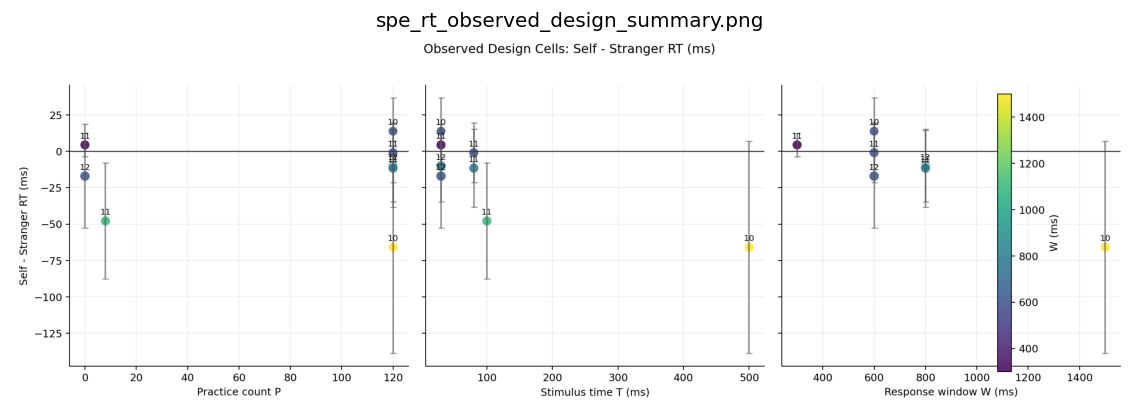

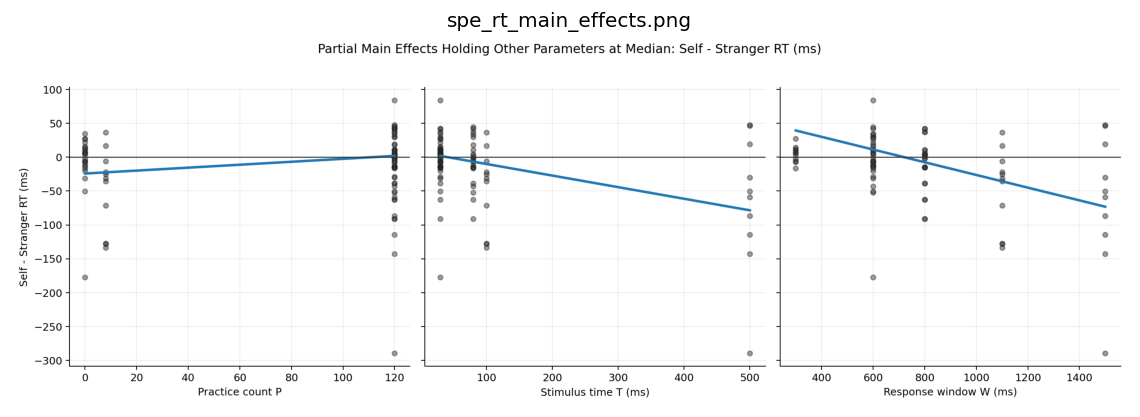

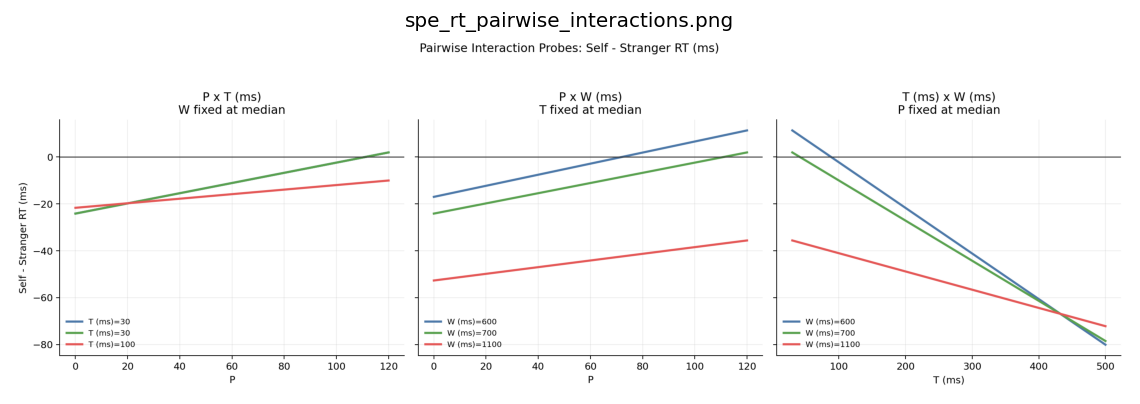

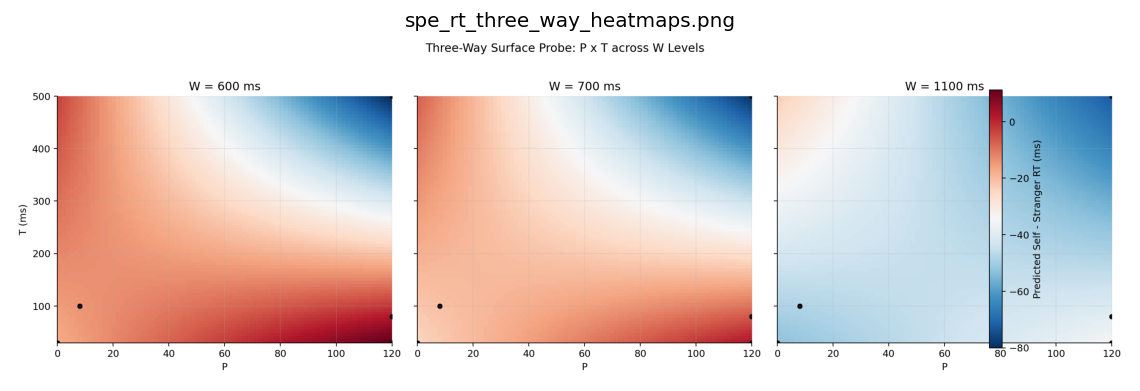

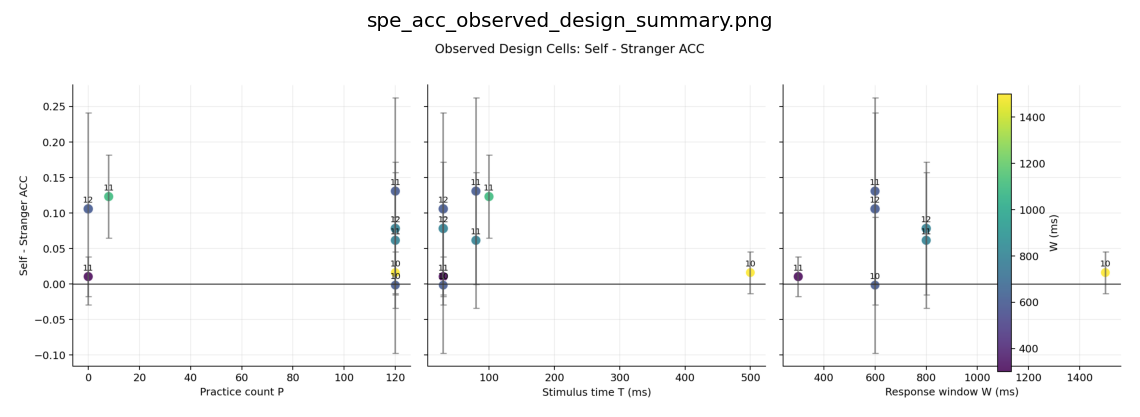

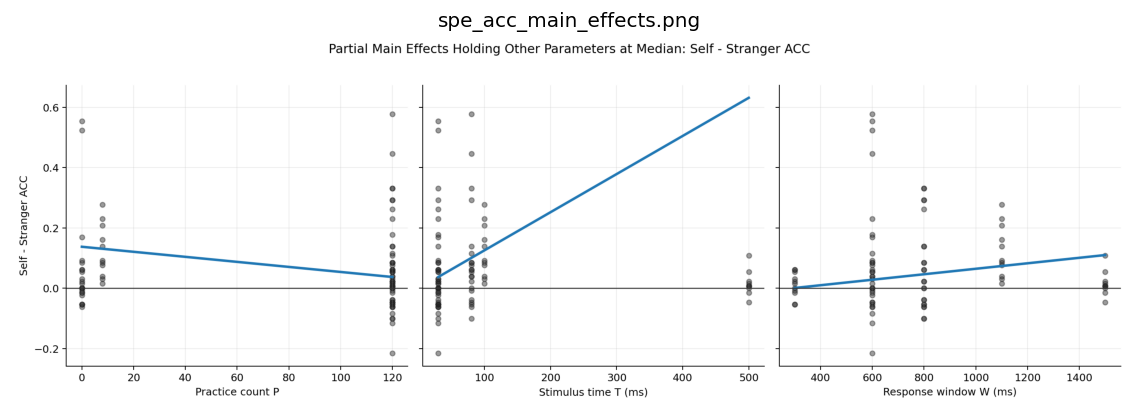

In [7]:
fig_paths = [
    DESIGN_OUT_DIR / "spe_rt_observed_design_summary.png",
    DESIGN_OUT_DIR / "spe_rt_main_effects.png",
    DESIGN_OUT_DIR / "spe_rt_pairwise_interactions.png",
    DESIGN_OUT_DIR / "spe_rt_three_way_heatmaps.png",
    DESIGN_OUT_DIR / "spe_acc_observed_design_summary.png",
    DESIGN_OUT_DIR / "spe_acc_main_effects.png",
]

for fig_path in fig_paths:
    img = plt.imread(fig_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(fig_path.name)
    plt.show()

## 7. 描述统计

In [8]:
spe_rt_summary = (
    spe_rt.groupby(["DesignCell", "P", "T_ms", "W_ms"], observed=True)["SPE_RT_ms"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values(["P", "T_ms", "W_ms"])
)
spe_acc_summary = (
    spe_acc.groupby(["DesignCell", "P", "T_ms", "W_ms"], observed=True)["SPE_ACC"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .sort_values(["P", "T_ms", "W_ms"])
)

display(spe_rt_summary)
display(spe_acc_summary)

,DesignCell,P,T_ms,W_ms,mean,std,count
0,P0_T30_W300,0,30.0,300.0,4.336649,12.044936,11
1,P0_T30_W600,0,30.0,600.0,-17.050831,56.318033,12
2,P8_T100_W1100,8,100.0,1100.0,-47.857717,59.366399,11
3,P120_T30_W600,120,30.0,600.0,13.753530,32.019230,10
4,P120_T30_W800,120,30.0,800.0,-10.160307,38.394362,12
5,P120_T80_W600,120,80.0,600.0,-0.981887,30.535281,11
6,P120_T80_W800,120,80.0,800.0,-11.623802,39.915758,11
7,P120_T500_W1500,120,500.0,1500.0,-65.937246,101.642386,10


,DesignCell,P,T_ms,W_ms,mean,std,count
0,P0_T30_W300,0,30.0,300.0,0.010490,0.041320,11
1,P0_T30_W600,0,30.0,600.0,0.105769,0.212749,12
2,P8_T100_W1100,8,100.0,1100.0,0.123077,0.087164,11
3,P120_T30_W600,120,30.0,600.0,-0.001538,0.133914,10
4,P120_T30_W800,120,30.0,800.0,0.078205,0.147303,12
5,P120_T80_W600,120,80.0,600.0,0.130769,0.195451,11
6,P120_T80_W800,120,80.0,800.0,0.061538,0.142131,11
7,P120_T500_W1500,120,500.0,1500.0,0.016154,0.041098,10
